# **랭체인 Multi-modal RAG 구현 [옵션 2]**

## **학습 목표**

이 노트북을 통해 다음 내용을 학습합니다:

- 멀티모달 RAG 옵션 2 (텍스트 요약 활용) 이해
- 이미지/테이블을 텍스트로 요약하여 RAG에 활용하는 방법
- MultiVectorRetriever를 사용한 parent-child 문서 관리

## **사전 준비**

- **Python 버전**: Python 3.10 이상
- **필수 패키지**: `langchain`, `langchain-openai`, `langchain-chroma`, `unstructured`
- **선수 학습**: Part1 노트북 학습 권장

---

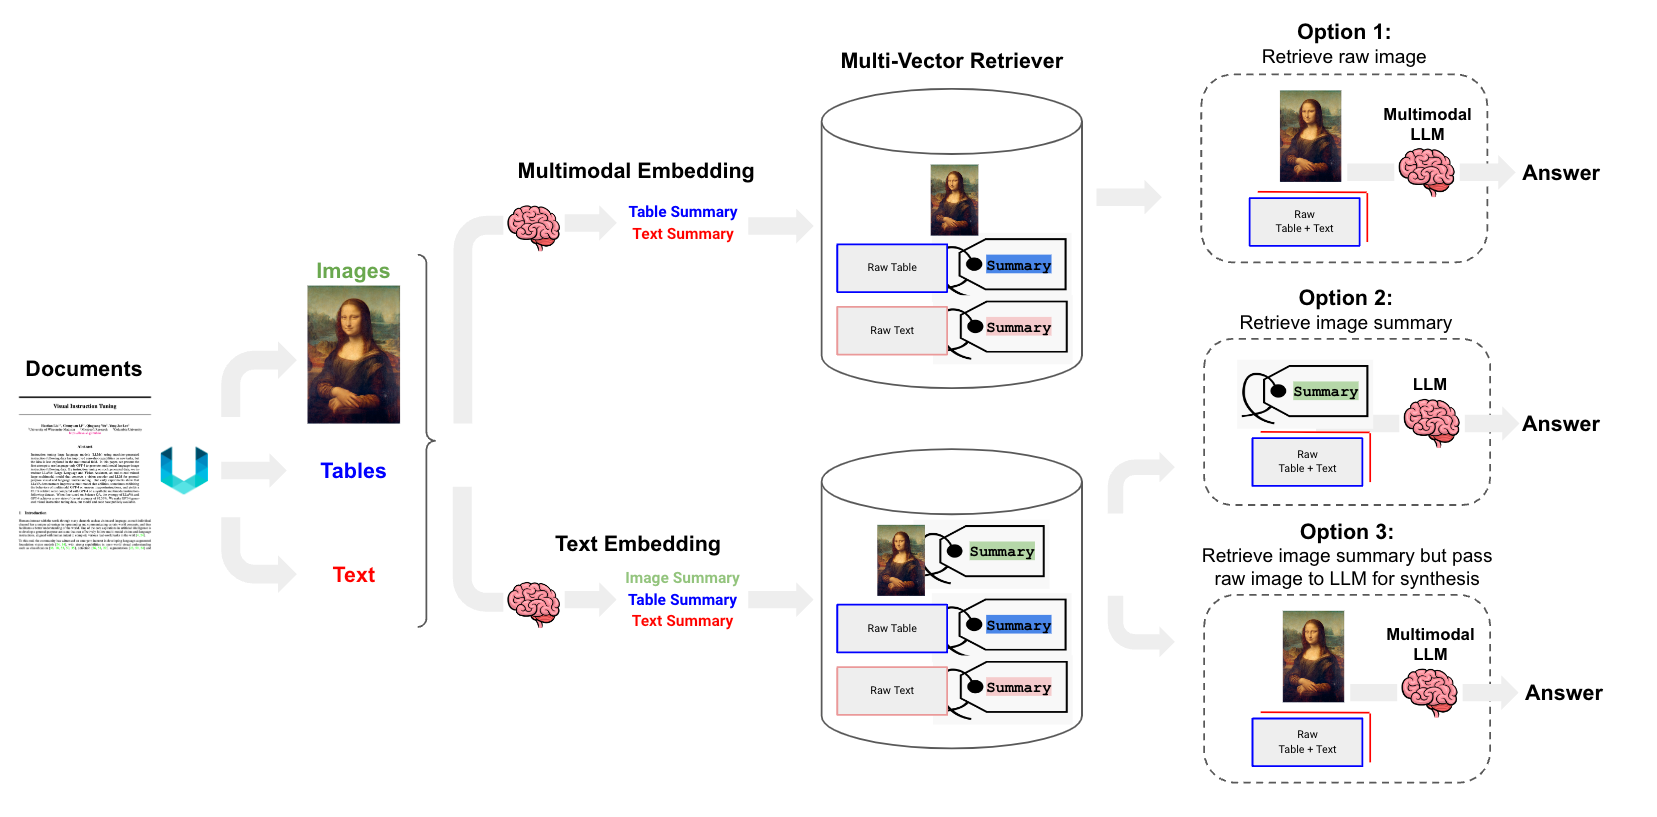

- 이미지 출처: https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb

**3가지 옵션 비교:**

| 옵션 | 임베딩 방식 | 벡터 DB 저장 | 답변 생성 LLM | 이미지 활용 | 장점 | 단점 |
|---|---|---|---|---|---|---|
| 1 | 멀티모달 (CLIP) | 이미지 임베딩, 텍스트 임베딩 | Multimodal | 직접 활용 (base64) | 최고 이미지 활용도, 높은 답변 품질 | 높은 비용, base64 오버헤드 |
| 2 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약) | Text-only | 텍스트 요약 간접 활용 | 비용 효율성, 텍스트 RAG 인프라 활용 | 이미지 정보 손실, 답변 품질 제한적 |
| 3 | 텍스트 (OpenAI) | 텍스트 임베딩 (이미지 요약 + 참조) | Multimodal | 원본 이미지 참조 활용 | 옵션 1과 2의 절충, 이미지 정보 손실 감소, 유연성 | 옵션 1보다 이미지 활용도 낮음, 이미지 참조 관리 필요 |

**선택 가이드:**

* **최고 품질 답변:** 옵션 1 (비용 고려)
* **비용 효율성 우선:** 옵션 2 (답변 품질 제한 감수)
* **품질과 효율성 균형:** 옵션 3

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

`(3) langfuse handler 설정`

In [3]:
# from langfuse.langchain import CallbackHandler

# # 콜백 핸들러 생성
# langfuse_handler = CallbackHandler()

`(4) 유틸리티 함수`

In [4]:
import base64
import io
from io import BytesIO

import numpy as np
from PIL import Image
from IPython.display import HTML, display
from langchain_core.documents import Document

import pickle
from langchain_core.stores import InMemoryStore


def is_base64(s):
    """문자열이 Base64로 인코딩되었는지 확인합니다"""
    try:
        return base64.b64encode(base64.b64decode(s)) == s.encode()
    except Exception:
        return False


def split_image_text_types(docs):
    """numpy 배열 이미지와 텍스트를 분리합니다"""
    images = []
    text = []
    for doc in docs:
        if isinstance(doc, str):
            pass
        elif isinstance(doc, Document):
            doc = doc.page_content  # 문서 내용 추출
        else:
            doc = doc.text # 문서 내용 추출

        if is_base64(doc):
            images.append(doc)  # base64로 인코딩된 문자열
        else:
            text.append(doc)
    return {"images": images, "texts": text}


def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 이미지를 주피터 노트북에 표시
    
    매개변수:
    img_base64 (str): Base64로 인코딩된 이미지 문자열
    """
    # Base64 문자열을 소스로 하는 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'

    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))

---

## **증권사 분석보고서 문서 로드**

- PDF 문서에서 이미지, 텍스트, 테이블 분리


### 1. **데이터 로딩 및 파싱** 

- 메모리 부족할 경우 별도의 실습파일을 활용 

In [5]:
# 데이터 저장 폴더 경로
data_path = "data/analyst_reports/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "*.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/analyst_reports/20240531_company_652771000.pdf',
 'data/analyst_reports/20240524_company_234017000.pdf',
 'data/analyst_reports/20240531_company_753270000.pdf']


In [6]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
# ⚠️ 중요: chunking_strategy="by_title" 은 일부 chunk 의 metadata.filename 을
#   None 으로 남기는 버그성 동작이 있어, 파싱 직후 강제로 filename 을 기록합니다.
pdf_chunks = []
for pdf_file in pdf_files:
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",
        infer_table_structure=True,
        languages=["eng", "kor"],

        # 이미지 추출 설정
        extract_image_block_types=["Image", "Table"],
        # extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
        extract_image_block_to_payload=True,  # base64로 저장

        # 후처리 설정
        post_processors=[
            group_broken_paragraphs,
            clean_extra_whitespace,
        ],

        # 문서 청킹 설정
        chunking_strategy="by_title",
        max_characters=1200,
        new_after_n_chars=800,
        combine_text_under_n_chars=600,
    )

    # 강제 filename 기록 — chunk 와 orig_elements 모두
    fn = os.path.basename(pdf_file)
    for ch in chunks:
        meta = getattr(ch, "metadata", None)
        if meta is None:
            continue
        if not getattr(meta, "filename", None):
            meta.filename = fn
        orig = getattr(meta, "orig_elements", None)
        if orig:
            for el in orig:
                el_meta = getattr(el, "metadata", None)
                if el_meta is not None and not getattr(el_meta, "filename", None):
                    el_meta.filename = fn

    pdf_chunks.extend(chunks)


# 청크 개수 확인
print(len(pdf_chunks))


The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


34


In [7]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
# ⚠️ 중요: chunking_strategy="by_title" 은 일부 chunk 의 metadata.filename 을
#   None 으로 남기는 버그성 동작이 있어, 파싱 직후 강제로 filename 을 기록합니다.
pdf_chunks = []
for pdf_file in pdf_files:
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",
        infer_table_structure=True,
        languages=["eng", "kor"],

        # 이미지 추출 설정
        extract_image_block_types=["Image", "Table"],
        # extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
        extract_image_block_to_payload=True,  # base64로 저장

        # 후처리 설정
        post_processors=[
            group_broken_paragraphs,
            clean_extra_whitespace,
        ],

        # 문서 청킹 설정
        chunking_strategy="by_title",
        max_characters=1200,
        new_after_n_chars=800,
        combine_text_under_n_chars=600,
    )

    # 강제 filename 기록 — chunk 와 orig_elements 모두
    fn = os.path.basename(pdf_file)
    for ch in chunks:
        meta = getattr(ch, "metadata", None)
        if meta is None:
            continue
        if not getattr(meta, "filename", None):
            meta.filename = fn
        orig = getattr(meta, "orig_elements", None)
        if orig:
            for el in orig:
                el_meta = getattr(el, "metadata", None)
                if el_meta is not None and not getattr(el_meta, "filename", None):
                    el_meta.filename = fn

    pdf_chunks.extend(chunks)


# 청크 개수 확인
print(len(pdf_chunks))


34


In [8]:
# 타입별 분석
chunk_types = {}
for chunk in pdf_chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

📋 청크 타입 분포:
  • CompositeElement': 26개
  • TableChunk': 8개


In [9]:
# 청크 내용 확인
for chunk in pdf_chunks[1:3]:
    print(chunk)
    print("=" * 100)

ㆍ 25 년 예상 BPS 기준 19796[『/8 1.9 배 를 적 용 해 목 표 가 를 20 만 원 으로 상 향 하고 투 자 의견 BUY 유지.

주 가 원 530) 156,600 시 가 총 액 (십억원) 11,697 . ： 발 행 주식수 | 74.694 천 주 2 주 최고가 165.000 원 none 119,108 52 주 일간 Beta 0.90 아이지 05 다 소 이 르이 cy 배 당 수 익 률 (2024) 13% 주 주 구성 삼 성 전 자 (의 621) 23.8% 국 민 연 금 공단 ( 외 1 인 ) 10.4% 주 가 상 승 (%) 1M 6M 12M 상 대 기준 26 3.5 34 절 대 기준 04 75 5.3 _ (원, 십억원) 현재 직전 변동 투 자 의견 BUY BUY - 목 표 주가 200,000 160,000 A 영 업 이 익 (24) 878 955 영 업 이 익 (250 1.099 1,131

12 월 결 산 십억 ——«2023A-—«2024E ~—2025E ~2026E 매출액 8909 10,121 10919 11,787 영 업 이익 639 878 1099 1,261 세 전 손익 543 830 1001 1178 당 기 순이익 450 713 863 1015 EPS(@) 5663 8999 10,735 12,629 증 감 률 (%) 569 589 193 176 PER(HH) 277 174 146 124 ROE(%) 55 86 100 108 PBR(HH) 15 16 15 13 EVIEBITDACH) 80 67 49 44

자르 유 진 투 자 증권

180,000 주 가 ( 좌 , 원 ) 050 지 수 대 비 ( 우 , 0 110 160,000 100 100.000 ] 90 100000 | 80 80,000 4 70 60,000 | 40,000 + 60 20,000 4 50 0 + 40 23.5 23.9 24.1
삼 성 전 기

삼 성 전 기 (009150.9) 재 무 제표

대 차 대조표

( 단 위 : 십 억원) 20224 20234 20240 202 

In [10]:
# 청크 저장
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "wb") as f:
    pickle.dump(pdf_chunks, f)

In [11]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

34


### 2. **타입별 구조 확인** 

In [12]:
# 각 청크 문서의 타입 확인
set([str(type(el)) for el in pdf_chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.TableChunk'>"}

In [13]:
# CompositeElement 확인
pdf_chunks[1]

In [14]:
# CompositeElement는 하위 구성 요소를 포함하고 있음
pdf_chunks[1].metadata.orig_elements

In [15]:
# Table 객체 확인 
tab = pdf_chunks[1].metadata.orig_elements[3] 
tab.to_dict()

{'type': 'UncategorizedText',
 'element_id': 'e1291a92-d3b2-49ab-a01d-c7c789b5b037',
 'text': '자르 유 진 투 자 증권',
 'metadata': {'coordinates': {'points': ((915.0, 1863.0),
    (915.0, 1916.0),
    (1072.0, 1916.0),
    (1072.0, 1863.0)),
   'system': 'PixelSpace',
   'layout_width': 1654,
   'layout_height': 2339},
  'last_modified': '2026-04-21T19:35:31',
  'filetype': 'PPM',
  'languages': ['eng', 'kor'],
  'page_number': 1,
  'filename': '20240531_company_652771000.pdf'}}

In [16]:
tab.metadata



In [17]:
from unstructured.documents.elements import Table

# text_as_html이 있는 모든 Table 요소 자동 탐색
tables = []
for chunk in pdf_chunks:
    orig = getattr(chunk.metadata, 'orig_elements', None)
    if not orig:
        continue
    for el in orig:
        if isinstance(el, Table) and getattr(el.metadata, 'text_as_html', None):
            tables.append(el)

if not tables:
    print("text_as_html이 있는 Table 요소를 찾을 수 없습니다.")
else:
    print(f"총 {len(tables)}개의 Table 요소를 찾았습니다.")
    for i, tab in enumerate(tables, 1):
        # Table 객체의 데이터프레임 변환
        tab_df = pd.read_html(tab.metadata.text_as_html)[0]
        print(f"\n[Table {i}]")
        display(tab_df)

,0,1,2,3
0,시 가 총 액 ( 십 억원),NaN,NaN,11697
1,발 행 주식수 2 주 최고가 최저가,NaN,NaN,"74,694 천 주 165,000 원 119,100 원"
2,삼 성 전 자 ( 외 인 ) 민 연 금 공단 ( 외 1 인,NaN,NaN,10.4%
3,주 가 상 승 (%),1M,6M,12M
4,상 대 기준,26,3.5,34
5,준,04,75,53
6,irc) o> Sry 2 오,현재,직전,변동
7,JO,BUY,BUY,-
8,. 으 4y 으 TO AS 끈,"200,000 878","160,000 955",>


In [18]:
# 데이터프레임을 마크다운 변환
tab_md = tab_df.to_markdown(index=False)
print(tab_md)

| 0                                             | 1           | 2           | 3                                  |
|:----------------------------------------------|:------------|:------------|:-----------------------------------|
| 시 가 총 액 ( 십 억원)                        | nan         | nan         | 11697                              |
| 발 행 주식수 2 주 최고가 최저가               | nan         | nan         | 74,694 천 주 165,000 원 119,100 원 |
| 삼 성 전 자 ( 외 인 ) 민 연 금 공단 ( 외 1 인 | nan         | nan         | 10.4%                              |
| 주 가 상 승 (%)                               | 1M          | 6M          | 12M                                |
| 상 대 기준                                    | 26          | 3.5         | 34                                 |
| 준                                            | 04          | 75          | 53                                 |
| irc) o> Sry 2 오                              | 현재        | 직전        | 변동                               |
| JO             


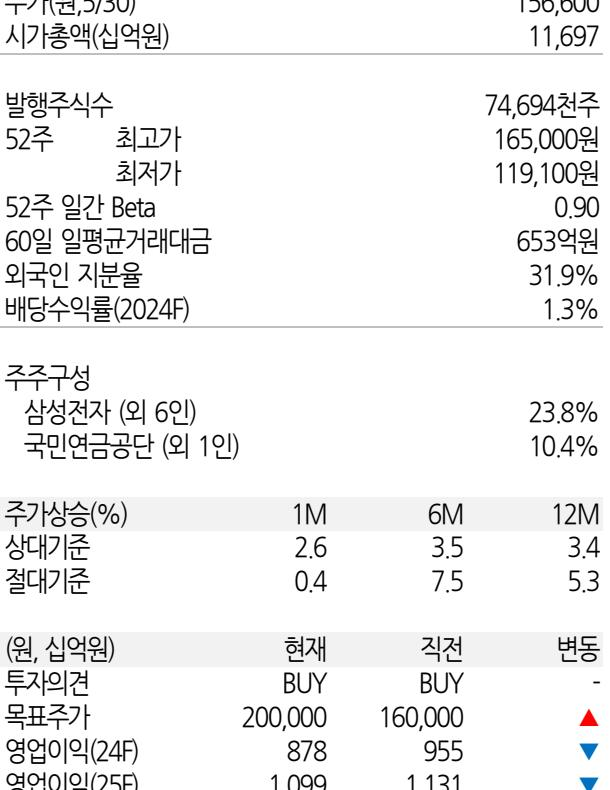

In [19]:
# image_base64 이미지 확인
plt_img_base64(tab.metadata.image_base64)

In [20]:
# TableChunk 객체 확인
for i, c in enumerate(pdf_chunks):
    if "TableChunk" in str(type(c)):
        print(f"TableChunk {i}:")
        print(c)
        print("=" * 100)

TableChunk 3:
( 단 위 : 십 억원) 20224 20234 2024 202 다 2026 영 업 현금 1575 1,180 1,276 1,893 1,975 당 기 순이익 994 450 713 863 1,015 자 산 상각비 879 837 918 1,216 = 1,185 기 타 비 현 금 성 손익 442 278 (855) (172) _ (200) 운 전 자 본 증감 (432) (301) 308 (137) _ (150) 매 출 채 권 감 소 (증가) 145 (229) 211 (83) (91) 재 고 자 산 감 소 (증가) _ (230) (283) 294 (141) _ (154) 매 입 채 무 증 가 (감소) (428) 111 (283) 86 94 기 티 82 101 86 1 1 투 자 현금 (1,328) (1,023) (1,333) (1,092) (1,077) 단 기 투 자 자 산 감소 0 0 (2) (2) (3) 장 기 투 자 증 권 감소 0 0 (2) 6) 10 설 비 투지 1.297 1,210 1,273 1,000 1,000 유 형 자 산 처분 17 5 1 0 0 무 형 자 산 처분 (49) (47) (64) (67) (67) 재 무 현금 193 (173) 326 130 175 차 입 금 증 2 398 77 489 324 369 자 본 증가 (062) (159) (163) _ (0194) _ (194) 배 당 금 지급 162 159 163 194 194 현금 증감 444 (8) 270 930 1,072 기 초 현금 1.233 _ 1,677 1,669 1,939 2,869 기 말 현금 1.677 _ 1,669 _ 1.939 2.869 3,941 Gross Cash flow 2,315 1,616 968 2,030 2,125 Gross Investment 1,759 1,324 1,023 1,227 1,225 Free Cash Flow 555 292 (55) 803 900
TableChunk 4:
손 익 계산서 ( 단 위 : 십 억원) 2022A = 202

In [21]:
# TableChunk 객체 확인
pdf_chunks[4].metadata.orig_elements

In [22]:
tab = pdf_chunks[4].metadata.orig_elements[0]

# Table 객체 확인
tab.to_dict()

{'type': 'Table',
 'element_id': '59e36c69-9ced-49b8-83b6-9e092cbb6669',
 'text': '손 익 계산서 -( 단 위 : 십 억원) 2022A 20234 20240 202 다 2026 매출액 9425 8909 10,121 10919 11,787 증 가 율 (%) 216 (55) 136 79 80 매출원가 7.161 7,189 8257 8774 9,470 매 출 총 이익 2263 1,721 1865 2,145 2,317 판매 및 일 반 관리비 = 1,080 1,081 987 1,046 1,056 기 타 영 업 손익 2 0 (2) 6 1 영 업 이익 1,183 639 878 1.099 1,261 증 가 율 (%) 296 (459) 373 252 148 80006 2,062 1,476 1,796 2315 2,446 증 가 율 (%) 175 (284) _ 217 289 57 영 업 외 손 익 4 (96) (48) (98) (640 이 자 수익 30 57 43 40 43 이 자 비용 46 68 75 73 85 지 분 법 손익 (3) (4) 0 5 22 기 타 영 업 손익 24 (81) 06) 00 (640 세 전 순이익 1,187 543 830 1.001 1178 증 가 율 (%) 366 (542) 528 206 176 법 인 세 비용 164 85 117 138 163 당 기 순이익 994 450 713 863 1,015 증 가 율 (%) 593 (547) 582 210 176 지 배 주 주 지분 981 423 672 802 943 증 가 율 (%) 624 (569) 589 193 176 비 지 배 지 분 13 28 40 에 71 EPS(2) 13,128 5,663 8999 10735 12,629 증 가 율 (%) 624 (569) 589 193 176 수 정 655( 원 ) 13,128 5,579 8899 10,635 12,529 증 가 율 (%) 624 (575) 595 195 178 주 요 투 자 지표 20

In [23]:
# Table 객체의 데이터프레임 변환
table_df = pdf_chunks[4].metadata.orig_elements[0].metadata.text_as_html
table_df = pd.read_html(table_df)[0]  # 첫 번째 테이블

# 데이터프레임 확인
table_df

,손 익 계산서 ( 단 위 : 십 억원),2022A,= 20234,202 사,202 다,2026
0,매출액,9425,8909,10121,10919,11787
1,증 가 율 (%),21.6,(5.5),13.6,79,8.0
2,매출원가,7161,7189,8257,8774,970
3,매 출 총 이익,2.263,1721,1865,2145,2317
4,판매 및 일 반 관리비,1080,1081,987,1046,1056
5,기 타 영 업 손익,2,0,(9),6,1
6,영 업 이익,1183,639,878,1099,1261
7,증 가 율 (%),296,(45.9),373,25.2,148
8,EBITDA,2062,1476,1796,2315,2446
9,S718 (%),17.5,(28.4),217,289,5.7


---

## **[옵션 2]** 멀티모달 LLM으로 이미지 요약을 활용해서 생성

- **멀티모달 LLM** 모델(GPT4-V, LLaVA 등)을 사용하여 이미지에서 **텍스트 요약**을 생성
- 생성된 텍스트를 **임베딩**하고 필요할 때 **검색**
- 검색된 텍스트 **청크**를 LLM에 전달하여 최종 **답변을 합성**
- 이미지를 직접 벡터화하는 대신 이미지에서 **추출한 텍스트 정보**를 활용

### 1. **타입 별로 구분해서 요약 생성** 

- Table, Text, 이미지 요소를 구분해서 정리
- Table -> 텍스트 요약 
- Image -> 텍스트 요약

`(1) 타입별 구분`

In [24]:
import os

# 타입별 분류
tables = []
texts = []
images = []
image_metas = []  # 이미지와 평행한 page_number / filename 메타 (실습에서 활용)


def _resolve_filename(meta):
    """chunk 의 source PDF filename 을 안전하게 반환.

    1) meta.filename — 기본 경로 (cell 12 force-set 이 적용됐으면 여기서 항상 해결)
    2) meta.orig_elements 내부 element 의 filename 폴백 — unstructured 가
       by_title 청킹 시 top-level 에만 filename 을 잃는 경우 대비

    ⚠️ 어떤 경우에도 '추측' 하지 않음 — 위 2 단계 모두 실패하면 None 반환.
    """
    fn = getattr(meta, "filename", None)
    if fn:
        return fn
    orig = getattr(meta, "orig_elements", None)
    if orig:
        for el in orig:
            inner = getattr(el.metadata, "filename", None)
            if inner:
                return inner
    return None


for chunk in pdf_chunks:
    # 테이블 청크
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    # 텍스트 청크 (CompositeElement)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

# 이미지 추출 (metadata에서) — page_number / filename 도 같이 추적
for chunk in pdf_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            # 이미지 요소가 있는 경우만 추출
            if hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)
                image_metas.append({
                    "page_number": getattr(el.metadata, "page_number", None),
                    "filename": _resolve_filename(el.metadata),
                })

print(f"📊 테이블 청크: {len(tables)}개")
print(f"📝 텍스트 청크: {len(texts)}개")
print(f"🖼️ 이미지: {len(images)}개")

# 진단: filename 미해결 청크 수 — 0 
_none_text = sum(1 for t in texts if _resolve_filename(t.metadata) is None)
_none_table = sum(1 for t in tables if _resolve_filename(t.metadata) is None)
_none_image = sum(1 for m in image_metas if m["filename"] is None)
if _none_text or _none_table or _none_image:
    print(
        f"⚠️ filename 미해결: texts={_none_text}, tables={_none_table}, images={_none_image}"
        "\n    → cell 12 (force-set filename) 를 재실행해야 출처가 정확히 기록됩니다."
    )
else:
    print("✅ 모든 chunk 의 filename 해결됨")


📊 테이블 청크: 8개
📝 텍스트 청크: 26개
🖼️ 이미지: 33개
✅ 모든 chunk 의 filename 해결됨


In [25]:
# 테이블 청크 확인
tables[0]

In [26]:
# 텍스트 청크 확인
texts[0]


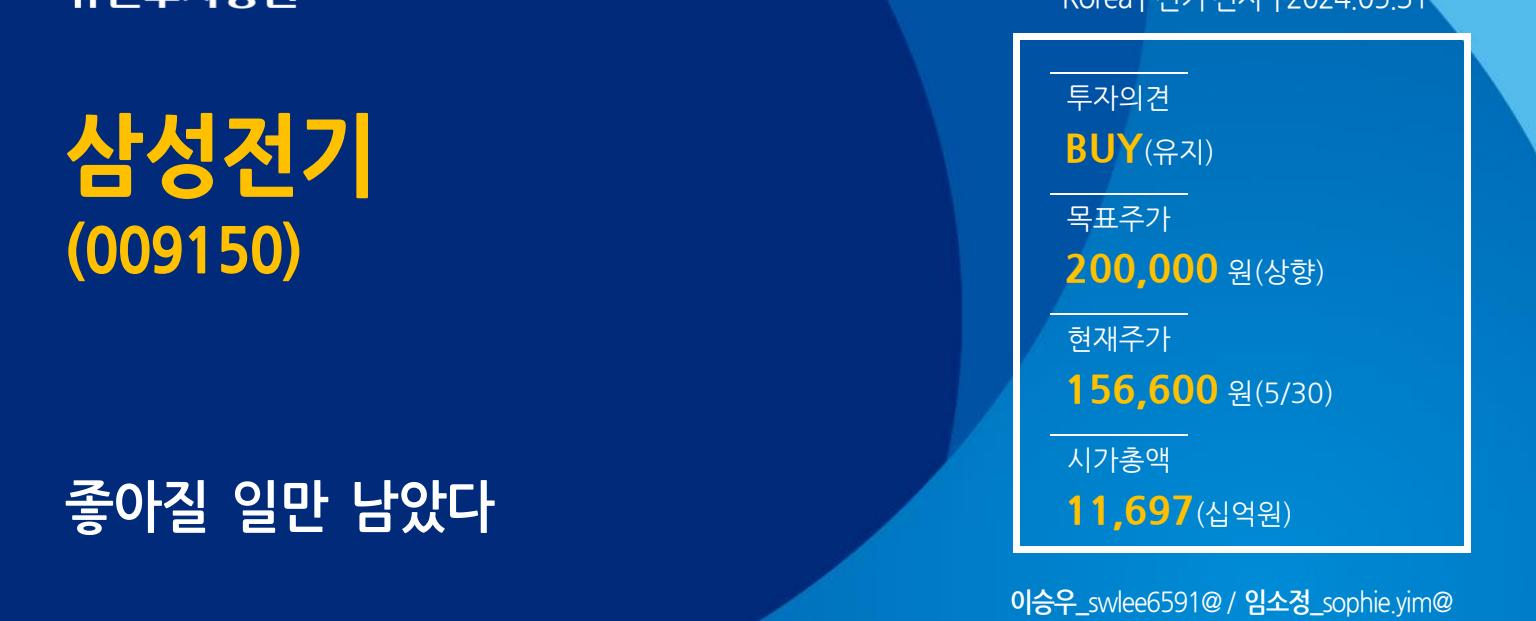

In [27]:
# 이미지 청크 확인
plt_img_base64(images[0])

`(2) Table/Text 요약 체인`

In [28]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# 프롬프트 템플릿 설정
prompt_text = """
다음 텍스트나 표를 한국어로 간결하게 요약하세요.
핵심 정보와 수치 데이터를 포함하되, 불필요한 설명은 제외하세요.

요약할 내용:
{element}

요약:
"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# 요약 체인 생성
model = ChatOpenAI(temperature=0, model="gpt-4.1-mini")
summarize_chain = prompt | model | StrOutputParser()

In [29]:
# 텍스트 요약 테스트
text_summary = summarize_chain.invoke(texts[0])
print(text_summary)

1분기 HAS 매출 6,243억 원(전년비 +30%), 영업이익 1,803억 원(+29%) 기록.  
- 컴포넌트 사업부: 출하량 감소에도 제품 믹스 개선으로 매출 전기비 +5% 증가.  
- 광학통신솔루션 사업부: 플래그십 모델 조기 출시 및 고부가 제품 확대에 힘입어 매출 전기비 +32% 증가.  
- 패키지솔루션 사업부: 일부 시장 수요 부진으로 매출 전기비 -3% 감소.  

2024년 AAS 예상 매출 10조 1,212억 원, 영업이익 8,779억 원.  
- 컴포넌트 사업부: 제품 믹스 개선과 재고 감소로 완만한 회복 전망.  
- 광학통신솔루션 사업부: 상반기 신제품 감소, 하반기 신제품 출시로 매출 회복 기대.  
- 패키지솔루션 사업부: 서버 교체 수요 증가 및 PC 교체 주기 도래로 하반기 회복 예상.


In [30]:
# 테이블 요약 테스트
table_summary = summarize_chain.invoke(tables[0])
print(table_summary)

요약:  
- 영업현금흐름(단위: 십억원): 2022년 1,575 → 2023년 1,180 → 2024년 1,276 → 2025년 1,893 → 2026년 1,975  
- 당기순이익: 994 → 450 → 713 → 863 → 1,015  
- 자산상각비: 879 → 837 → 918 → 1,216 → 1,185  
- 투자현금흐름: -1,328 → -1,023 → -1,333 → -1,092 → -1,077  
- 설비투자: 1,297 → 1,210 → 1,273 → 1,000 → 1,000  
- 차입금증가: 2 → 398 → 77 → 489 → 324  
- 배당금지급: 162 → 159 → 163 → 194 → 194  
- 현금증감: 444 → -8 → 270 → 930 → 1,072  
- 기말현금: 1,677 → 1,669 → 1,939 → 2,869 → 3,941  
- Gross Cash Flow: 2,315 → 1,616 → 968 → 2,030 → 2,125  
- Gross Investment: 1,759 → 1,324 → 1,023 → 1,227 → 1,225  
- Free Cash Flow: 555 → 292 → -55 → 803 → 900


In [31]:
# 텍스트 요약
text_summaries = summarize_chain.batch(
    texts, 
    {"max_concurrency": 3}     # 동시 실행 개수 설정
    )

# 테이블 요약
table_summaries = summarize_chain.batch(
    tables, 
    {"max_concurrency": 3}     # 동시 실행 개수 설정
)

print(f"Text 요약 개수: {len(text_summaries)}")
print(f"Table 요약 개수: {len(table_summaries)}")

Text 요약 개수: 26
Table 요약 개수: 8


`(3) 이미지 캡션 요약 체인`

In [32]:
from langchain_openai import ChatOpenAI

# 이미지 요약 프롬프트 템플릿 설정
messages = [
    (
        "user",
        [
            {
                "type": "text", 
                "text": """
                이 이미지를 자세히 분석하고 한국어로 설명하세요. 
                특히 다음 사항에 주의하세요:
                
                1. 차트나 그래프의 경우: 데이터 트렌드, 수치, 비교 포인트
                2. 다이어그램의 경우: 구조, 연결관계, 프로세스 흐름
                3. 표의 경우: 주요 데이터 포인트와 패턴
                4. 일반 이미지의 경우: 주요 객체, 텍스트, 맥락
                
                분석 결과를 구체적이고 정확하게 기술하세요.
                """
            },
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

image_chain = prompt | ChatOpenAI(model="gpt-4.1-mini") | StrOutputParser()


# 이미지 요약 테스트
image_summary = image_chain.invoke(images[0])
print(image_summary)

이 이미지는 삼성전기(종목코드 009150)에 대한 투자 의견을 요약한 투자 리포트의 일부로 보입니다. 

주요 내용은 다음과 같습니다:

1. 종목 및 기업명
- 삼성전기(009150)

2. 슬로건 및 평가
- "좋아질 일만 남았다"라는 긍정적인 문구가 포함되어 있어 향후 주가나 실적 개선에 대한 기대감을 나타냅니다.

3. 투자 의견
- BUY (유지) : 현재 매수 의견을 유지하고 있음
- 목표 주가: 200,000원 (상향 조정된 목표가로 추정됨)
- 현재 주가: 156,600원 (2024년 5월 30일 기준)
- 시가총액: 11,697십억원 (즉, 약 11조 6,970억원 규모)

4. 맥락
- 목표 주가가 현재 주가보다 약 28% 높은 수준으로 설정되어 있어 상승 여력이 크다고 평가함
- "좋아질 일만 남았다"는 문구와 BUY 유지 의견이 이를 뒷받침함

요약하자면, 이 이미지는 삼성전기에 대해 긍정적 전망을 제시하며, 현재 주가 대비 상당한 상승 여력이 있다고 판단하여 매수 의견을 유지하는 투자 보고서의 간단한 핵심 데이터를 보여주고 있습니다.


In [33]:
# 이미지 요약
image_summaries = image_chain.batch(
    images, 
    {"max_concurrency": 3}
)

print(f"Image 요약 개수: {len(image_summaries)}")

Image 요약 개수: 33


In [34]:
# 추출한 이미지와 요약 결과를 저장할 폴더 경로
output_dir = "data/analyst_reports/summaries"
os.makedirs(output_dir, exist_ok=True)

# 요약 결과를 JSON 파일로 저장
summary_data = {
    "text_summaries": text_summaries,
    "table_summaries": table_summaries,
    "image_summaries": image_summaries
}
with open(os.path.join(output_dir, "summaries.json"), "w", encoding="utf-8") as f:
    json.dump(summary_data, f, ensure_ascii=False, indent=4)

### 2. **RAG** 

`(1) 벡터스토어에 저장`

In [35]:
from langchain_core.stores import InMemoryStore
import pickle

def save_store_to_disk(store: InMemoryStore, path: str):
    """InMemoryStore를 디스크에 저장"""
    data = dict(store.store)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"💾 Store 저장: {path}")


def load_store_from_disk(path: str):
    """디스크에서 InMemoryStore 로드"""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    new_store = InMemoryStore()
    new_store.store = data
    return new_store

In [36]:
import uuid

from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

# 자식 청크를 인덱싱하기 위한 벡터 저장소
vectorstore = Chroma(
    collection_name="mm_summaries", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # 벡터 저장소 경로
)

# 부모 문서를 위한 저장 레이어
store = InMemoryStore()
# id_key 변수를 사용하여 일관성 유지 권장
id_key = "doc_id"

# 검색기 생성
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

In [37]:
# retriever.vectorstore.delete_collection()  # 기존 컬렉션 삭제

In [38]:
### 텍스트 추가 ###

# 각 텍스트에 대한 고유 ID 생성
doc_ids = [str(uuid.uuid4()) for _ in texts]

# 텍스트 요약 문서 생성 (요약 자체에도 메타 부착 → 검색 결과 확인 시 유용)
summary_texts = [
    Document(
        page_content=s,
        metadata={
            id_key: doc_ids[i],
            "source": "text",
            "page_number": getattr(texts[i].metadata, "page_number", None),
            "doc_name": _resolve_filename(texts[i].metadata),  # ★ 폴백 적용
        },
    )
    for i, s in enumerate(text_summaries)
]

# 원본 텍스트 문서 생성 (★ page_number / doc_name 메타 추가 — 실습에서 사용)
original_texts = [
    Document(
        page_content=t.text,
        metadata={
            id_key: doc_ids[i],
            "source": "text",
            "page_number": getattr(t.metadata, "page_number", None),
            "doc_name": _resolve_filename(t.metadata),  # ★ 폴백 적용
        },
    )
    for i, t in enumerate(texts)
]

# 벡터 저장소에 텍스트 요약 추가
retriever.vectorstore.add_documents(summary_texts)

# 문서 저장소에 원본 텍스트 추가
retriever.docstore.mset(list(zip(doc_ids, original_texts)))

print(f"📄 텍스트 요약 추가: {len(summary_texts)}개")


📄 텍스트 요약 추가: 26개


In [39]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: cd07c2ec-6193-4768-b459-284b770bb4e6
Source: text
Content: 00,000 156,600 11,697

ㆍ 1 분 기 HAS 매출 22 6,243 억 원, 영 업 이익 1,803 억 원 으로 각각 전년비 30%, 29% 증가. (8 컴 포 넌 트 사 업 부 는 부진한 세트 수 요 에도 불 구 하고 시 관련 산업용 제 품 과 전 장 용 제품 매출 비중 증 가 에 따른 제품 믹스 개 선 으로 출 하 량 감 소 에도 전 기...
ID: 315f029e-b190-474e-bbfa-883b49f688cc
Source: text
Content: 주 가

( 원 5/30) 106,300 시 가 총 액 (십억원) 17,396 발 행 주식수 163,648 천 주 22 최고가 132.400 원 최저가 90.300 원 52% 일간 Beta 1.05 60% 일 평 균 거 래 대금 719 억 원 외국인 지분율 311% 배 당 수 익 를 (20248 07% . aan LG (2| 3 인 ) 33.7% 국 민 연...
ID: b1a6a2fa-c467-4f43-bc25-03c9ef860557
Source: text
Content: 50,000 106,300 17,396

ㆍ {분기 AAS 매출 212 959 억 원, 영 업 이익 12 3,354 억 원 으로 전 사 업 부 의 매 출 이 전년비 증 가 했지만 LCD 패널 가격 상승, 마케팅 비용 증가 등 원가 부담 요 인 으로 인해 수 익 성 은 소폭 하락. 07184 사 업 부는 글로벌 경기 둔화 에도 불구, 보급형 제품 물량 확 대...
ID: 8fa7e291-a69c-4f53-b24f-fa2a9a4a98ef
Source: text
Content: ㆍ 25 년 예상 BPS 기준 19796[『/8 1.9 배 를 적 용 해 목 표 가 를 20 만 원 으로 상 향 하고 투 자 의견 BUY 유지.

주 가 원 530) 156,600 시 가 총 액 (십억원) 11,697

In [40]:
### 테이블 요약 추가 ###

# 각 테이블에 대한 고유 ID 생성
table_ids = [str(uuid.uuid4()) for _ in table_summaries]

# 테이블 요약 문서 생성 (메타 부착)
summary_tables = [
    Document(
        page_content=s,
        metadata={
            id_key: table_ids[i],
            "source": "table",
            "page_number": getattr(tables[i].metadata, "page_number", None),
            "doc_name": _resolve_filename(tables[i].metadata),  # ★ 폴백 적용
        },
    )
    for i, s in enumerate(table_summaries)
]

# 원본 테이블 문서 생성 — Table element 는 metadata.text_as_html 직접 보유
original_tables = [
    Document(
        page_content=getattr(t.metadata, "text_as_html", None) or t.text,
        metadata={
            id_key: table_ids[i],
            "source": "table",
            "page_number": getattr(t.metadata, "page_number", None),
            "doc_name": _resolve_filename(t.metadata),  # ★ 폴백 적용
        },
    )
    for i, t in enumerate(tables)
]

# 벡터 저장소에 테이블 요약 추가
retriever.vectorstore.add_documents(summary_tables)

# 문서 저장소에 원본 테이블 추가
retriever.docstore.mset(list(zip(table_ids, original_tables)))

print(f"📄 테이블 요약 추가: {len(summary_tables)}개")


📄 테이블 요약 추가: 8개


In [41]:
# 검색 테스트
query = "2023년 2분기 매출은 얼마인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: 9b77d11a-2fa3-4c00-b3d6-d3d6b5fd0508
Source: table
Content: <table><tr><td>손 익 계산서</td><td/><td/><td/><td/><td/></tr><tr><td>( 단 위 : 십 억원)</td><td>20224</td><td>2023A</td><td>2024F</td><td>2025F</td><td>2026F</td></tr><tr><td>매출액</td><td>2284</td><td>2176</td>...
ID: 8a2f32b2-3168-4d86-9c10-f30621bf4c40
Source: table
Content: <table><tr><td>손 익 계산서 ( 단 위 : 십 억원)</td><td>2022A</td><td>= 20234</td><td>202 사</td><td>202 다</td><td>2026</td></tr><tr><td>매출액</td><td>9425</td><td>8909</td><td>10,121</td><td>10,919</td><td>11,787<...
ID: cd07c2ec-6193-4768-b459-284b770bb4e6
Source: text
Content: 00,000 156,600 11,697

ㆍ 1 분 기 HAS 매출 22 6,243 억 원, 영 업 이익 1,803 억 원 으로 각각 전년비 30%, 29% 증가. (8 컴 포 넌 트 사 업 부 는 부진한 세트 수 요 에도 불 구 하고 시 관련 산업용 제 품 과 전 장 용 제품 매출 비중 증 가 에 따른 제품 믹스 개 선 으로 출 하 량 감 소 에도 전 기...
ID: 315f029e-b190-474e-bbfa-883b49f688cc
Source: text
Content: 주 가

( 원 5/30) 106,300 시 가 총 액 (십억원) 17,396 발 행 주식수 163,648 천 주 22 최고가 132.400 원 최저가 90.300 원 52% 일간 Beta 1.05 60% 일 평 

In [42]:
### 이미지 요약 추가 ###

# 각 이미지에 대한 고유 ID 생성
img_ids = [str(uuid.uuid4()) for _ in image_summaries]

# 이미지 요약 문서 생성 (★ page_number / doc_name 메타 추가)
summary_images = [
    Document(
        page_content=s,
        metadata={
            id_key: img_ids[i],
            "source": "image",
            "page_number": image_metas[i]["page_number"] if i < len(image_metas) else None,
            "doc_name": image_metas[i]["filename"] if i < len(image_metas) else None,
        },
    )
    for i, s in enumerate(image_summaries)
]

# # 벡터 저장소에 이미지 요약 추가
retriever.vectorstore.add_documents(summary_images)

# 문서 저장소에 이미지 요약 추가
retriever.docstore.mset(list(zip(img_ids, summary_images)))

print(f"📄 이미지 요약 추가: {len(summary_images)}개")


📄 이미지 요약 추가: 33개


In [43]:
# 검색 테스트
query = "삼성전기의 과거 2년간 투자 의견은 무엇인가요?"
docs = retriever.invoke(query)
print(f"🔍 검색 결과 개수: {len(docs)}개")

for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

🔍 검색 결과 개수: 4개
ID: d59d1454-c43a-4604-86ae-3cf6fd0bd3a4
Source: image
Content: 이 이미지는 삼성전기(009150)라는 기업에 대한 투자 의견을 요약한 자료입니다. 한국어로 된 텍스트 중심의 이미지로, 주요 내용을 자세히 분석하면 다음과 같습니다.

1. 기업명 및 종목코드:
   - 삼성전기
   - 종목코드: 009150

2. 슬로건 또는 평가 문구:
   - "좋아질 일만 남았다"라는 긍정적인 메시지가 포함되어 있어, 앞으로 삼...
ID: dbb62ede-5025-4e08-91f7-5cc70052e39d
Source: text
Content: 투 자 기간 및 투 자 등 급 / 투 자 의 견

투 자 기간 및 투 자 등 급 / 투 자 의 견 종 목 추천 및 업 종 추천 투 자 기간: 12 개 월 {( 추 천 기 준 일 종 가 대비 추 천 종 목 의 예상 목 표 수 익 률 을 의 미 함 ) 당사 투 자 의견 비 율 (%) - STRONG BUY (OH) 추 천 기준일 종 가 대비 +50% 이 상 1...
ID: 1660d291-dbe9-4501-8774-3f475b97c9b0
Source: image
Content: 이 이미지는 삼성전기(009150.KS)의 주가와 목표주가 변동 내역을 분석한 표와 그래프로 구성되어 있습니다. 담당 애널리스트는 이승우입니다.

### 1. 표 분석 (과거 2년간 투자 의견 및 목표주가 변동내역)
- **추천일자**: 2022년 11월 30일부터 2024년 5월 31일까지 총 5회에 걸쳐 투자 의견이 제시됨
- **투자의견**: 모두 '...
ID: bf8a8ecc-7c3d-407a-9a90-1dc3d20056f5
Source: text
Content: 삼 성 전 기

삼 성 전 기 (009150.9) 재 무 제표

대 차 대조표

( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007

In [44]:
# store 저장
save_store_to_disk(store, "mm_summaries.pkl")

💾 Store 저장: mm_summaries.pkl


In [45]:
# store 로드
loaded_store = load_store_from_disk("mm_summaries.pkl")

# 벡터 저장소 로드
vectorstore = Chroma(
    collection_name="mm_summaries", 
    embedding_function=OpenAIEmbeddings(model="text-embedding-3-small"),
    persist_directory="./chroma_db",  # 벡터 저장소 경로
)

# 로드한 저장소로 새 검색기 만들기
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,  
    docstore=loaded_store,
    id_key=id_key,
)

# 벡터 스토어에서 문서 검색 
docs = retriever.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")
print(f"검색된 문서 개수: {len(docs)}")

검색된 문서 개수: 4


In [46]:
for doc in docs:
    print(f"ID: {doc.metadata[id_key]}")
    print(f"Source: {doc.metadata.get('source', 'unknown')}")
    print(f"Content: {doc.page_content[:200]}...")  # 내용 일부만 출력
    print("=" * 50)

ID: bf8a8ecc-7c3d-407a-9a90-1dc3d20056f5
Source: text
Content: 삼 성 전 기

삼 성 전 기 (009150.9) 재 무 제표

대 차 대조표

( 단 위 : 십 억원) 20224 20234 20240 202 202 자 산 총계 10.997 11,658 11,969 13,007 14,240 유 동 자산 4888 5,208 5,050 6208 7,529 현 금 성 자산 1737 17728 2.000 2933 4007 매 ...
ID: 1660d291-dbe9-4501-8774-3f475b97c9b0
Source: image
Content: 이 이미지는 삼성전기(009150.KS)의 주가와 목표주가 변동 내역을 분석한 표와 그래프로 구성되어 있습니다. 담당 애널리스트는 이승우입니다.

### 1. 표 분석 (과거 2년간 투자 의견 및 목표주가 변동내역)
- **추천일자**: 2022년 11월 30일부터 2024년 5월 31일까지 총 5회에 걸쳐 투자 의견이 제시됨
- **투자의견**: 모두 '...
ID: 8fa7e291-a69c-4f53-b24f-fa2a9a4a98ef
Source: text
Content: ㆍ 25 년 예상 BPS 기준 19796[『/8 1.9 배 를 적 용 해 목 표 가 를 20 만 원 으로 상 향 하고 투 자 의견 BUY 유지.

주 가 원 530) 156,600 시 가 총 액 (십억원) 11,697 . ： 발 행 주식수 | 74.694 천 주 2 주 최고가 165.000 원 none 119,108 52 주 일간 Beta 0.90 아이지 ...
ID: d03a37fd-0dec-4fb7-9e6a-34223a933300
Source: image
Content: 이 이미지는 2024년과 2025년의 분기별 실적 전망을 표로 나타낸 것입니다. 단위는 십억원이며, 매출액, 영업이익, 순이익, 영업이익률, 순이익률의 항목별 수치를 보여줍니다.

1. **매출액**:  
- 2024년 1분기 737십억원에

`(2) RAG 파이프라인`

- **검색된 텍스트 청크**를 그대로 LLM에 전달하는 **방식**을 적용
- 검색 엔진에서 가져온 텍스트 정보를 **그대로 컨텍스트**로 사용
- 이미지 처리 없이 **텍스트만 활용**하는 전통적인 RAG 파이프라인 실행 방식

In [47]:
from operator import itemgetter

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI

# 프롬프트 템플릿
template = """Answer the question based only on the following context, which can include text and tables:

<Context>
{context}
</Context>

<Question>
{question}
</Question>

Answer in 한국어:
"""
prompt = ChatPromptTemplate.from_template(template)

# 텍스트 기반 LLM
model = ChatOpenAI(temperature=0, model="gpt-4.1-mini") 

# RAG 파이프라인 구성
chain = (
    {"context": retriever, "question": RunnablePassthrough()}  # retriever로 컨텍스트 검색 및 질문 그대로 전달
    | prompt  # 프롬프트 템플릿에 컨텍스트와 질문 통합
    | model  # LLM을 통한 응답 생성
    | StrOutputParser()  # 출력을 문자열로 변환
)

# Langfuse 트레이싱 활성화:
# result = chain.invoke(query, config={"callbacks": [langfuse_handler]})

In [48]:
# chain 실행
result = chain.invoke("삼성전기의 2024년 실적은 어떻게 전망하고 있나요?")

# 결과 출력
print(result)

삼성전기의 2024년 실적은 매출과 수익성 모두 큰 폭으로 개선될 것으로 전망되고 있습니다.

- **매출액**은 2024년 1분기 737십억원에서 4분기 1,072십억원으로 지속 증가하며, 연간 매출은 약 3,499십억원으로 예상됩니다.
- **영업이익**은 1분기 15십억원에서 4분기 277십억원으로 크게 증가하여 연간 569십억원에 달할 것으로 보입니다.
- **순이익**도 1분기 22십억원에서 4분기 202십억원으로 증가하며, 연간 464십억원 수준이 예상됩니다.
- **영업이익률**은 1분기 2%에서 4분기 26%로 크게 개선되고, 연간 기준으로는 16%에 이를 것으로 전망됩니다.
- **순이익률**도 1분기 3%에서 4분기 19%로 상승하며, 연간 13% 수준이 예상됩니다.

종합하면, 2024년 삼성전기는 매출 성장과 함께 영업이익 및 순이익이 크게 증가하고, 수익성도 크게 개선되는 긍정적인 실적이 기대됩니다.


In [49]:
# chain 실행
result = chain.invoke("삼성전기의 과거 2년간 투자 의견은 무엇인가요?")

# 결과 출력
print(result)

삼성전기의 과거 2년간 투자 의견은 일관되게 "Buy" (매수)입니다.


### 기존 text_summaries + 페이지 메타 인용 

In [50]:
# 페이지별 메타데이터를 활용한 RAG 파이프라인
# (docstore Document 가 page_number / doc_name 메타를 보유)

import os
from collections import defaultdict
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI

# 단일 PDF fallback (unstructured 가 일부 chunk filename 을 잃을 때 표시용)
try:
    _DEFAULT_DOC = os.path.basename(pdf_files[0]) if len(pdf_files) == 1 else None
except NameError:
    _DEFAULT_DOC = None


def _disp(v, fallback="Unknown"):
    """None / 빈 문자열을 안전하게 fallback 으로 치환."""
    return v if (v is not None and v != "") else fallback


# 1) 페이지 정보를 살리는 컨텍스트 포맷터
def format_docs_with_pages(docs):
    """검색 결과를 (문서, 페이지) 단위로 그룹핑하여 포맷팅."""
    grouped = defaultdict(list)
    for d in docs:
        doc_name = _disp(d.metadata.get("doc_name"), _DEFAULT_DOC or "Unknown")
        page_no = _disp(d.metadata.get("page_number"))
        grouped[(doc_name, page_no)].append(d.page_content[:800])

    blocks = []
    for (doc_name, page_no), contents in grouped.items():
        body = "\n---\n".join(contents)
        blocks.append(f"[출처: {doc_name} | 페이지 {page_no}]\n{body}")
    return "\n\n".join(blocks)


# 2) 프롬프트 (페이지 인용 강제)
template = """다음 컨텍스트를 바탕으로 질문에 답변하세요.
각 컨텍스트 블록의 헤더([출처: ... | 페이지 N])를 답변에 명시적으로 인용하세요.

<Context>
{context}
</Context>

<Question>
{question}
</Question>

답변 작성 시 다음 사항을 포함하세요:
1. 질문에 대한 명확한 답변
2. 정보의 출처 (문서명과 페이지 번호) — 반드시 인용
3. 관련된 핵심 데이터나 수치

답변은 한국어로 작성하세요.
"""
prompt = ChatPromptTemplate.from_template(template)
model = ChatOpenAI(temperature=0, model="gpt-4.1-mini")

# 3) 페이지 메타데이터 인용 RAG 체인
chain_with_pages = (
    {"context": retriever | format_docs_with_pages, "question": RunnablePassthrough()}
    | prompt
    | model
    | StrOutputParser()
)

# 4) 테스트
test_queries = [
    "삼성전기의 2024년 실적 전망은 어떻게 되나요?",
    "과거 투자 의견의 변화 추이를 설명해주세요.",
    "주요 재무 지표의 변화는 어떻게 되나요?",
]

print("=" * 80)
print("🔍 페이지 메타데이터 인용 RAG 시스템 테스트")
print("=" * 80)

for q in test_queries:
    print(f"\n질문: {q}")
    print("-" * 80)
    print(chain_with_pages.invoke(q))
    print("=" * 80)


🔍 페이지 메타데이터 인용 RAG 시스템 테스트

질문: 삼성전기의 2024년 실적 전망은 어떻게 되나요?
--------------------------------------------------------------------------------
삼성전기의 2024년 실적 전망은 다음과 같습니다.

1. **매출액**: 2024년 연간 매출액은 3,499십억원으로 예상되며, 분기별로는 1분기 737십억원에서 4분기 1,072십억원으로 지속적인 증가세를 보입니다.  
2. **영업이익**: 2024년 연간 영업이익은 569십억원으로 전망되며, 분기별로는 1분기 15십억원에서 4분기 277십억원으로 크게 증가하여 수익성이 크게 개선될 것으로 예상됩니다.  
3. **순이익**: 2024년 연간 순이익은 464십억원으로 예상되며, 분기별로는 1분기 22십억원에서 4분기 202십억원으로 증가하는 추세입니다.  
4. **영업이익률 및 순이익률**: 2024년 영업이익률은 1분기 2%에서 4분기 26%로 대폭 상승하며, 연간 기준으로는 약 16% 수준입니다. 순이익률도 1분기 3%에서 4분기 19%로 상승할 것으로 보입니다.

이와 같은 전망은 2024년 삼성전기의 실적이 전반적으로 크게 개선되고 성장할 것임을 시사합니다.

[출처: 20240524_company_234017000.pdf | 페이지 6]

질문: 과거 투자 의견의 변화 추이를 설명해주세요.
--------------------------------------------------------------------------------
과거 투자 의견의 변화 추이를 살펴보면, 셀트리온(068270.KS)의 경우 2022년 5월 31일부터 2024년 5월 24일까지 약 2년간의 기간 동안 투자 의견은 일관되게 "Buy(매수)"로 유지되었습니다. 즉, 해당 기간 동안 매수 의견이 지속되었으며, 투자 의견의 등급 변화는 없었습니다. 다만, 목표 주가의 변동은 있었는데, 초기 250,000원에서 2022년 

---
## **[실습]**

- 트랜스포머 논문(data/transformer.pdf)에 대한 멀티모달 RAG 시스템을 구현합니다. (옵션 2 방식)

In [52]:
# 여기에 코드를 작성하세요. 

In [53]:
# 데이터 저장 폴더 경로
data_path = "data/" 

# PDF 파일이 있는  경로
pdf_files = glob(os.path.join(data_path, "transformer.pdf"))  

# 이미지를 저장할 경로
image_output_dir = os.path.join(data_path, 'images')  

os.makedirs(image_output_dir, exist_ok=True)

print(f"PDF files:")
pprint(pdf_files)

PDF files:
['data/transformer.pdf']


In [54]:
from unstructured.partition.pdf import partition_pdf
from unstructured.cleaners.core import (
    clean_extra_whitespace,
    group_broken_paragraphs
)

# PDF 파일을 로드하고 파티셔닝
# ⚠️ 중요: chunking_strategy="by_title" 은 일부 chunk 의 metadata.filename 을
#   None 으로 남기는 버그성 동작이 있어, 파싱 직후 강제로 filename 을 기록합니다.
pdf_chunks = []
for pdf_file in pdf_files:
    chunks = partition_pdf(
        filename=pdf_file,
        strategy="hi_res",
        infer_table_structure=True,
        languages=["eng", "kor"],

        # 이미지 추출 설정
        extract_image_block_types=["Image", "Table"],
        # extract_image_block_output_dir=image_output_dir,   # 이미지 저장 경로
        extract_image_block_to_payload=True,  # base64로 저장

        # 후처리 설정
        post_processors=[
            group_broken_paragraphs,
            clean_extra_whitespace,
        ],

        # 문서 청킹 설정
        chunking_strategy="by_title",
        max_characters=1200,
        new_after_n_chars=800,
        combine_text_under_n_chars=600,
    )

    # 강제 filename 기록 — chunk 와 orig_elements 모두
    fn = os.path.basename(pdf_file)
    for ch in chunks:
        meta = getattr(ch, "metadata", None)
        if meta is None:
            continue
        if not getattr(meta, "filename", None):
            meta.filename = fn
        orig = getattr(meta, "orig_elements", None)
        if orig:
            for el in orig:
                el_meta = getattr(el, "metadata", None)
                if el_meta is not None and not getattr(el_meta, "filename", None):
                    el_meta.filename = fn

    pdf_chunks.extend(chunks)


# 청크 개수 확인
print(len(pdf_chunks))


47


In [55]:
# 타입별 분석
chunk_types = {}
for chunk in pdf_chunks:
    chunk_type = str(type(chunk))
    if chunk_type in chunk_types:
        chunk_types[chunk_type] += 1
    else:
        chunk_types[chunk_type] = 1

print("📋 청크 타입 분포:")
for chunk_type, count in chunk_types.items():
    print(f"  • {chunk_type.split('.')[-1].replace('>', '')}: {count}개")

📋 청크 타입 분포:
  • CompositeElement': 46개
  • Table': 1개


In [56]:
# 청크 내용 확인
for chunk in pdf_chunks[1:3]:
    print(chunk)
    print("=" * 100)

Abstract

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English- to-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature. We show that 

In [58]:
# 청크 저장
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "wb") as f:
    pickle.dump(pdf_chunks, f)

In [59]:
# 청크 로드
import pickle

with open(os.path.join(data_path, "pdf_base64_chunks.pkl"), "rb") as f: 
    pdf_chunks = pickle.load(f)

# 청크 개수 확인
print(len(pdf_chunks))

47


In [61]:
# 각 청크 문서의 타입 확인
set([str(type(el)) for el in pdf_chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [125]:
# CompositeElement 확인
pdf_chunks[1]

In [129]:
# CompositeElement는 하위 구성 요소를 포함하고 있음
pdf_chunks[3].metadata.orig_elements

In [65]:
# Table 객체 확인 
tab = pdf_chunks[1].metadata.orig_elements[1] 
tab.to_dict()

{'type': 'NarrativeText',
 'element_id': '1dd1d35d-36bb-4563-97a9-f016d0cc32b4',
 'text': 'The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English- to-German translation task, improving over the existing best results, including ensembles, by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fra

In [66]:
tab.metadata

In [131]:
from unstructured.documents.elements import Table

# text_as_html이 있는 첫 번째 Table 요소 자동 탐색
tab = None
for chunk in pdf_chunks:
    orig = getattr(chunk.metadata, 'orig_elements', None)
    if not orig:
        continue
    for el in orig:
        if isinstance(el, Table) and getattr(el.metadata, 'text_as_html', None):
            tab = el
            break
    if tab:
        break

if tab is None:
    print("text_as_html이 있는 Table 요소를 찾을 수 없습니다.")
else:
    # Table 객체의 데이터프레임 변환
    tab_df = pd.read_html(tab.metadata.text_as_html)[0]
    display(tab_df)

,Layer Type,Complexity per Layer,Sequential Operations,Maximum Path Length
0,Self-Attention,O(n? - d),020),020)
1,Recurrent,O(n- d?),O(n),O(n)
2,Convolutional,O(k-n-d?),020),O(logx.(n))
3,Self-Attention (restricted),O(r-n-d),020),O(n/r)


In [132]:
from unstructured.documents.elements import Table

# text_as_html이 있는 모든 Table 요소 자동 탐색
tables = []
for chunk in pdf_chunks:
    orig = getattr(chunk.metadata, 'orig_elements', None)
    if not orig:
        continue
    for el in orig:
        if isinstance(el, Table) and getattr(el.metadata, 'text_as_html', None):
            tables.append(el)

if not tables:
    print("text_as_html이 있는 Table 요소를 찾을 수 없습니다.")
else:
    print(f"총 {len(tables)}개의 Table 요소를 찾았습니다.")
    for i, tab in enumerate(tables, 1):
        # Table 객체의 데이터프레임 변환
        tab_df = pd.read_html(tab.metadata.text_as_html)[0]
        print(f"\n[Table {i}]")
        display(tab_df)

총 4개의 Table 요소를 찾았습니다.

[Table 1]


,Layer Type,Complexity per Layer,Sequential Operations,Maximum Path Length
0,Self-Attention,O(n? - d),020),020)
1,Recurrent,O(n- d?),O(n),O(n)
2,Convolutional,O(k-n-d?),020),O(logx.(n))
3,Self-Attention (restricted),O(r-n-d),020),O(n/r)



[Table 2]


,Model,EN-DE _,BLEU EN-FR,Training EN-DE,Cost (FLOPs) EN-FR
0,ByteNet [18],23.75,NaN,NaN,NaN
1,Deep-Att + PosUnk [39],NaN,39.20,NaN,1.0- 107°
2,GNMT + RL [38],24.60,39.92,2.3-10!9,1.4-1070
3,ConvS2S [9],25.16,40.46,9.6-10'8,1.5. 1070
4,MoE [32],26.03,40.56,2.0-10'9,1.2. 1020
5,Deep-Att + PosUnk Ensemble [39],NaN,40.40,NaN,8.0 - 107°
6,GNMT + RL Ensemble [38],26.30,41.16,1.8-1079,1.1- 1074
7,ConvS2S Ensemble [9],26.36,41.29,7.7-10'9,1.9 . 107!
8,Transformer (base model),27.30,38.10,3.3 -,1018
9,Transformer (big),28.40,41.80,2.3-,1019



[Table 3]


,Unnamed: 0,N,dmoat,di,=,Rdg,Unnamed: 6,202,Unnamed: 8,train steps,PPL | (dev),BLEU (dev),params «10°
0,base,| 6,512.0,2048,8,64.0,64,0.1,0.1,100K,| 4.92,25.8,65.0
1,(A),NaN,NaN,NaN,1,512.0,512,NaN,NaN,NaN,5.29,24.9,NaN
2,(A),NaN,NaN,NaN,4,128.0,128,NaN,NaN,NaN,5.00,25.5,NaN
3,(A),NaN,NaN,NaN,16,32.0,32,NaN,NaN,NaN,4.91,25.8,NaN
4,(A),NaN,NaN,NaN,32,16.0,16,NaN,NaN,NaN,5.01,25.4,NaN
5,08),NaN,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN,5.16,25.1,58.0
6,08),NaN,NaN,NaN,NaN,32.0,NaN,NaN,NaN,NaN,5.01,25.4,60.0
7,(C),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.11,23.7,36.0
8,(C),4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.19,25.3,50.0
9,(C),8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,488,25.5,80.0



[Table 4]


,Parser,Training,WSJ 23 F1
0,Vinyals & Kaiser el al. (2014) [37],"| WSJ only, discriminative",88.3
1,Petrov et al. (2006) [29],"WSJ only, discriminative",90.4
2,Zhu et al. (2013) [40],"WSJ only, discriminative",90.4
3,Dyer et al. (2016) [8],"WSJ only, discriminative",91.7
4,Transformer (4 layers),"WSJ only, discriminative",91.3
5,Zhu et al. (2013) [40],semi-supervised,91.3
6,Huang & Harper (2009) [14],semi-supervised,91.3
7,McClosky et al. (2006) [26],semi-supervised,92.1
8,Vinyals & Kaiser el al. (2014) [37],semi-supervised,92.1
9,Transformer (4 layers),semi-supervised,92.7


In [68]:
# 데이터프레임을 마크다운 변환
tab_md = tab_df.to_markdown(index=False)
print(tab_md)

| Layer Type                  | Complexity per Layer   | Sequential Operations   | Maximum Path Length   |
|:----------------------------|:-----------------------|:------------------------|:----------------------|
| Self-Attention              | O(n? - d)              | 020)                    | 020)                  |
| Recurrent                   | O(n- d?)               | O(n)                    | O(n)                  |
| Convolutional               | O(k-n-d?)              | 020)                    | O(logx.(n))           |
| Self-Attention (restricted) | O(r-n-d)               | 020)                    | O(n/r)                |



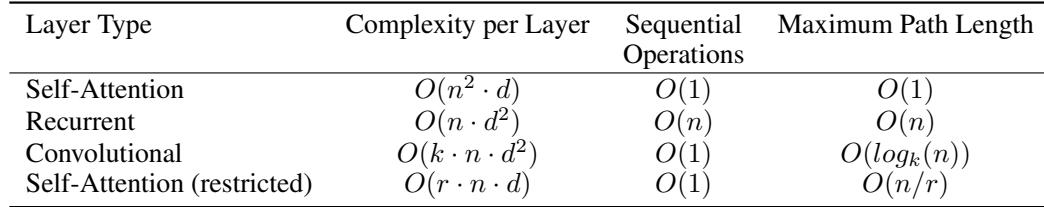

In [69]:
# image_base64 이미지 확인
plt_img_base64(tab.metadata.image_base64)

In [130]:
# TableChunk 객체 확인
for i, c in enumerate(pdf_chunks):
    if "TableChunk" in str(type(c)):
        print(f"type: {str(type(c))}")
        print(f"TableChunk {i}:")
        print(c)
        print("=" * 100)

In [75]:
# TableChunk 객체 확인
pdf_chunks[4].metadata.orig_elements

In [79]:
pdf_chunks[4].metadata.orig_elements

In [123]:
tab = pdf_chunks[4].metadata.orig_elements[0]

# Table 객체 확인
tab.to_dict()

{'type': 'Title',
 'element_id': '589c9d85-c50e-403a-883a-438ac70bd12d',
 'text': '1 Introduction',
 'metadata': {'detection_class_prob': 0.9067491888999939,
  'coordinates': {'points': ((295.11419677734375, 206.17437744140625),
    (295.11419677734375, 233.31761169433594),
    (536.1755981445312, 233.31761169433594),
    (536.1755981445312, 206.17437744140625)),
   'system': 'PixelSpace',
   'layout_width': 1700,
   'layout_height': 2200},
  'last_modified': '2026-04-14T21:43:03',
  'filetype': 'PPM',
  'languages': ['eng', 'kor'],
  'page_number': 2,
  'filename': 'transformer.pdf'}}

In [115]:
# Table 객체의 데이터프레임 변환
print(pdf_chunks[2].metadata)
# table_df = pdf_chunks[4].metadata.orig_elements[0].metadata.text_as_html
# table_df = pd.read_html(table_df)[0]  # 첫 번째 테이블

# 데이터프레임 확인
# table_df

In [133]:
import os

# 타입별 분류
tables = []
texts = []
images = []
image_metas = []  # 이미지와 평행한 page_number / filename 메타 (실습에서 활용)


def _resolve_filename(meta):
    """chunk 의 source PDF filename 을 안전하게 반환.

    1) meta.filename — 기본 경로 (cell 12 force-set 이 적용됐으면 여기서 항상 해결)
    2) meta.orig_elements 내부 element 의 filename 폴백 — unstructured 가
       by_title 청킹 시 top-level 에만 filename 을 잃는 경우 대비

    ⚠️ 어떤 경우에도 '추측' 하지 않음 — 위 2 단계 모두 실패하면 None 반환.
    """
    fn = getattr(meta, "filename", None)
    if fn:
        return fn
    orig = getattr(meta, "orig_elements", None)
    if orig:
        for el in orig:
            inner = getattr(el.metadata, "filename", None)
            if inner:
                return inner
    return None


for chunk in pdf_chunks:
    # 테이블 청크
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    # 텍스트 청크 (CompositeElement)
    elif "CompositeElement" in str(type(chunk)):
        texts.append(chunk)

# 이미지 추출 (metadata에서) — page_number / filename 도 같이 추적
for chunk in pdf_chunks:
    if hasattr(chunk, 'metadata') and hasattr(chunk.metadata, 'orig_elements'):
        for el in chunk.metadata.orig_elements:
            # 이미지 요소가 있는 경우만 추출
            if hasattr(el.metadata, 'image_base64') and el.metadata.image_base64:
                images.append(el.metadata.image_base64)
                image_metas.append({
                    "page_number": getattr(el.metadata, "page_number", None),
                    "filename": _resolve_filename(el.metadata),
                })

print(f"📊 테이블 청크: {len(tables)}개")
print(f"📝 텍스트 청크: {len(texts)}개")
print(f"🖼️ 이미지: {len(images)}개")

# 진단: filename 미해결 청크 수 — 0 
_none_text = sum(1 for t in texts if _resolve_filename(t.metadata) is None)
_none_table = sum(1 for t in tables if _resolve_filename(t.metadata) is None)
_none_image = sum(1 for m in image_metas if m["filename"] is None)
if _none_text or _none_table or _none_image:
    print(
        f"⚠️ filename 미해결: texts={_none_text}, tables={_none_table}, images={_none_image}"
        "\n    → cell 12 (force-set filename) 를 재실행해야 출처가 정확히 기록됩니다."
    )
else:
    print("✅ 모든 chunk 의 filename 해결됨")

📊 테이블 청크: 1개
📝 텍스트 청크: 46개
🖼️ 이미지: 10개
✅ 모든 chunk 의 filename 해결됨
